# AI Project

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
mnistX = mnist['data']
mnistX.shape

(70000, 784)

# Part 1 PCA:

First apply PCA to the training data to find the transformation into a lower dimensional space.
How many dimensions do we need to explain 90% of the total variation in the data?
Apply the SAME centering and projection to the test data,What dimension did we embed into?

A natural question to ask is what did we gain from this projection? Well, our algorithms will run MUCH
faster on the reduced dimension data. Will we sacrifice accuracy for this speed boost? For this section,
I would like you to run K-NN on the original data and on the reduced dimension
data from PCA (NOTE: IN YOUR WRITE-UP, PLEASE GIVE A SHORT TEXT DESCRIPTION OF
EACH CLASSIFIER BEFORE YOU USE IT).
Use 10-fold Cross validation repeated 10 times to tune K <Br>
• Consider K = 1, 2, 3, 4, 5, 6 in the repeated CV <Br>
• Include a running time evaluation <Br>
• Here I would like you to compare performance across data sets both based on accuracy (on the test 
data) AND on running time <Br>
• How do the estimated test accuracies obtained from Cross Validation compare with the accuracies on
the actual test data? Explain. <Br>

> The code cell below includes short classifier descriptions, full implementation, and a performance comparison of K-NN classifiers on both original and PCA-reduced MNIST data. I used 10-fold cross-validation repeated 10 times to evaluate K = 1 to 6.

In [3]:
# Description of Classifiers:
# PCA (Principal Component Analysis) reduces the number of features while retaining most of the variance.
# It simplifies the data and speeds up training.
# K-Nearest Neighbors (K-NN) is a classification algorithm that assigns class labels
# based on the majority class among the k nearest training examples.

# Step 1: Load and preprocess the MNIST fashion dataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import time

# Load dataset
mnist = fetch_openml('mnist_784', version=1)
X = mnist['data']
y = mnist['target'].astype(int)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Apply PCA to reduce dimensions while preserving 90% variance
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of components to explain 90% variance: {n_components}")

# Transform the data using PCA
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 3: Evaluate K-NN (k=1 to 6) on original and PCA-reduced data
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)
results = []

for k in range(1, 7):
    # Original data
    knn_orig = KNeighborsClassifier(n_neighbors=k)
    start = time.time()
    scores_orig = cross_val_score(knn_orig, X_train_scaled, y_train, cv=cv, n_jobs=-1)
    knn_orig.fit(X_train_scaled, y_train)
    test_acc_orig = accuracy_score(y_test, knn_orig.predict(X_test_scaled))
    end = time.time()
    results.append({
        'Data': 'Original',
        'K': k,
        'CV Accuracy': scores_orig.mean(),
        'Test Accuracy': test_acc_orig,
        'Runtime (s)': round(end - start, 2)
    })

    # PCA data
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    start = time.time()
    scores_pca = cross_val_score(knn_pca, X_train_pca, y_train, cv=cv, n_jobs=-1)
    knn_pca.fit(X_train_pca, y_train)
    test_acc_pca = accuracy_score(y_test, knn_pca.predict(X_test_pca))
    end = time.time()
    results.append({
        'Data': f'PCA ({n_components}D)',
        'K': k,
        'CV Accuracy': scores_pca.mean(),
        'Test Accuracy': test_acc_pca,
        'Runtime (s)': round(end - start, 2)
    })

# Step 4: Display results
results_df = pd.DataFrame(results)
print("\nPerformance Comparison:")
print(results_df)

Number of components to explain 90% variance: 235

Performance Comparison:
          Data  K  CV Accuracy  Test Accuracy  Runtime (s)
0     Original  1     0.944587       0.945429       171.96
1   PCA (235D)  1     0.953182       0.952357        60.19
2     Original  2     0.934811       0.936143       165.91
3   PCA (235D)  2     0.944596       0.943071        60.19
4     Original  3     0.945241       0.946500       168.84
5   PCA (235D)  3     0.953146       0.952643        60.57
6     Original  4     0.943009       0.944286       165.61
7   PCA (235D)  4     0.951707       0.951071        60.21
8     Original  5     0.944459       0.945786       169.51
9   PCA (235D)  5     0.952357       0.952571        61.75
10    Original  6     0.942752       0.943000       169.61
11  PCA (235D)  6     0.950486       0.950071        60.93


In [4]:
results_df

,Data,K,CV Accuracy,Test Accuracy,Runtime (s)
0,Original,1,0.944587,0.945429,171.96
1,PCA (235D),1,0.953182,0.952357,60.19
2,Original,2,0.934811,0.936143,165.91
3,PCA (235D),2,0.944596,0.943071,60.19
4,Original,3,0.945241,0.946500,168.84
5,PCA (235D),3,0.953146,0.952643,60.57
6,Original,4,0.943009,0.944286,165.61
7,PCA (235D),4,0.951707,0.951071,60.21
8,Original,5,0.944459,0.945786,169.51
9,PCA (235D),5,0.952357,0.952571,61.75


> After applying Principal Component Analysis (PCA) to the MNIST dataset, it was determined that 235 components are sufficient to retain 90% of the total variance. This reduced feature space was then used to train and evaluate a k-Nearest Neighbors (K-NN) classifier and compared against the model performance on the original 784-dimensional dataset. The PCA-reduced models consistently showed: Significantly faster runtime, with inference and training completing in ~60 seconds versus ~165–170 seconds for the original high-dimensional data. Improved cross-validation accuracy, with the PCA version achieving 95.3% at k = 1 and k = 3, compared to 94.5% for the original data. Higher or equivalent test accuracy, where the PCA-reduced model reached up to 95.26% (k = 3) compared to 94.65% for the original. Importantly, the difference between cross-validation accuracy and test accuracy remained small in both versions, indicating consistent generalization and validating the effectiveness of repeated cross-validation as an estimate of true performance. In summary, PCA not only reduced computational cost by more than 60% but also led to a slight improvement in model accuracy. These results suggest that dimensionality reduction via PCA can serve as a powerful preprocessing step in high-dimensional classification problems like MNIST, offering a favorable balance between efficiency and performance.

# Part 2 Comparing across classifiers:

For the next section, you will compare the performance of multiple classifiers (tuned via CV) on the test
data. You will run these classifiers on the dimension reduced PCA data (NOTE: IN YOUR WRITE-UP,
PLEASE GIVE A SHORT TEXT DESCRIPTION OF EACH CLASSIFIER BEFORE YOU USE IT). <Br>
• REMEMBER TO TRAIN THE FINAL MODEL ON THE FULL TRAINING SET AFTER TUNING
THE PARAMETERS <Br>
• I would like you to run the following classifiers using 10-fold CV repeated 5 times to tune the parameters <Br>
– Linear SVM <Br>
– Radial Basis SVM <Br>
• I would also like you to train a Random Forest <Br>
• I would also like you to train an LDA model <Br>
• I would also like you to train a QDA model <Br>
For each model, I would like you to compare across both test accuracy and running time. In particular, I
would like you to address <Br>
• (\*)Which model would you choose out of the above (including K-NN)? Why would you make this choice? <Br>
• For the models that provide a test error estimate (Random Forest via the error and the CV-tuned
models via cross validation), which would you have chosen based on the estimated test error? Explain
how this relates to your answer to question (\*)? <Br>
• For the models that do not immediately provide a test error estimate (LDA and QDA), how could you
estimate test error (Hint: CV)? <Br>

### Linear Support Vector Machine (Linear SVM)
Linear SVM is a supervised classification algorithm that constructs a hyperplane to separate data points belonging to different classes. It performs well in high-dimensional spaces and is particularly effective when the classes are linearly separable.
### Radial Basis Function Support Vector Machine (RBF SVM)
RBF SVM extends the basic SVM by using a radial basis function kernel to handle non-linear decision boundaries. It transforms the input space into a higher-dimensional space to find an optimal separating hyperplane, offering flexibility for more complex patterns.
### Random Forest
Random Forest is an ensemble method based on decision trees. It builds multiple trees on different subsets of the training data and aggregates their outputs for robust predictions. It is less sensitive to overfitting and provides internal estimates of generalization error through out-of-bag (OOB) evaluation.
### Linear Discriminant Analysis (LDA)
LDA is a statistical classifier that assumes multivariate normal distributions for each class with equal covariance matrices. It projects the data onto a space that maximizes class separability, using linear decision boundaries.
### Quadratic Discriminant Analysis (QDA)
QDA is similar to LDA but allows each class to have its own covariance matrix, enabling the model to fit more flexible, curved decision boundaries. While more expressive than LDA, QDA may be more sensitive to noise and small sample sizes.

In [5]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# X_train_pca, X_test_pca, y_train, y_test

cv_strategy = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)
model_results = []

# Linear SVM
param_grid_linear = {'C': [0.1, 1, 10]}
svc_linear = SVC(kernel='linear')
grid_linear = GridSearchCV(svc_linear, param_grid_linear, cv=cv_strategy, n_jobs=-1)
start = time.time()
grid_linear.fit(X_train_pca, y_train)
test_acc_linear = accuracy_score(y_test, grid_linear.predict(X_test_pca))
end = time.time()
model_results.append({
    'Model': 'Linear SVM',
    'Best Params': grid_linear.best_params_,
    'CV Score': grid_linear.best_score_,
    'Test Accuracy': test_acc_linear,
    'Runtime (s)': round(end - start, 2)
})

# RBF SVM
param_grid_rbf = {'C': [1, 10], 'gamma': ['scale', 0.01, 0.001]}
svc_rbf = SVC(kernel='rbf')
grid_rbf = GridSearchCV(svc_rbf, param_grid_rbf, cv=cv_strategy, n_jobs=-1)
start = time.time()
grid_rbf.fit(X_train_pca, y_train)
test_acc_rbf = accuracy_score(y_test, grid_rbf.predict(X_test_pca))
end = time.time()
model_results.append({
    'Model': 'RBF SVM',
    'Best Params': grid_rbf.best_params_,
    'CV Score': grid_rbf.best_score_,
    'Test Accuracy': test_acc_rbf,
    'Runtime (s)': round(end - start, 2)
})

# Random Forest
param_grid_rf = {'n_estimators': [100, 200]}
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=cv_strategy, n_jobs=-1)
start = time.time()
grid_rf.fit(X_train_pca, y_train)
test_acc_rf = accuracy_score(y_test, grid_rf.predict(X_test_pca))
end = time.time()
model_results.append({
    'Model': 'Random Forest',
    'Best Params': grid_rf.best_params_,
    'CV Score': grid_rf.best_score_,
    'Test Accuracy': test_acc_rf,
    'Runtime (s)': round(end - start, 2)
})

# LDA
lda = LinearDiscriminantAnalysis()
start = time.time()
lda.fit(X_train_pca, y_train)
test_acc_lda = accuracy_score(y_test, lda.predict(X_test_pca))
end = time.time()
model_results.append({
    'Model': 'LDA',
    'Best Params': 'N/A',
    'CV Score': 'N/A',
    'Test Accuracy': test_acc_lda,
    'Runtime (s)': round(end - start, 2)
})

# QDA
qda = QuadraticDiscriminantAnalysis()
start = time.time()
qda.fit(X_train_pca, y_train)
test_acc_qda = accuracy_score(y_test, qda.predict(X_test_pca))
end = time.time()
model_results.append({
    'Model': 'QDA',
    'Best Params': 'N/A',
    'CV Score': 'N/A',
    'Test Accuracy': test_acc_qda,
    'Runtime (s)': round(end - start, 2)
})

# Show results
results_df = pd.DataFrame(model_results)
print("Model Comparison on PCA-Reduced Data:\n")
print(results_df)

/devel/data_access/software/tdp-jupyter/poetry/cache/virtualenvs/python311-IuuSel2o-py3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/devel/data_access/software/tdp-jupyter/poetry/cache/virtualenvs/python311-IuuSel2o-py3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/devel/data_access/software/tdp-jupyter/poetry/cache/virtualenvs/python311-IuuSel2o-py3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/devel/data_acce

Model Comparison on PCA-Reduced Data:

           Model                  Best Params  CV Score  Test Accuracy  \
0     Linear SVM                   {'C': 0.1}  0.940582       0.939214   
1        RBF SVM  {'C': 10, 'gamma': 'scale'}  0.974743       0.974071   
2  Random Forest        {'n_estimators': 200}  0.940643       0.943214   
3            LDA                          N/A       N/A       0.868786   
4            QDA                          N/A       N/A       0.763071   

   Runtime (s)  
0     11002.64  
1     18499.63  
2      2709.76  
3         1.26  
4         1.58  


In [6]:
results_df

,Model,Best Params,CV Score,Test Accuracy,Runtime (s)
0,Linear SVM,{'C': 0.1},0.940582,0.939214,11002.64
1,RBF SVM,"{'C': 10, 'gamma': 'scale'}",0.974743,0.974071,18499.63
2,Random Forest,{'n_estimators': 200},0.940643,0.943214,2709.76
3,LDA,N/A,N/A,0.868786,1.26
4,QDA,N/A,N/A,0.763071,1.58


> Explanation: In this section, I evaluate and compare the performance of multiple classifiers on the MNIST fashion dataset after reducing its dimensionality using Principal Component Analysis (PCA). The PCA transformation retained 90% of the total variance and reduced the feature space from 784 to 235 components. Results Summary: The models were trained using 10-fold cross-validation repeated 5 times (where applicable), then evaluated on a held-out test set. All training and evaluation were performed on the PCA-reduced dataset. Among the classifiers evaluated, the RBF SVM achieved the highest performance with a cross-validation accuracy of 97.47% and a test accuracy of 97.41%. However, this came at a high computational cost the training and evaluation took nearly 18,500 seconds. The Random Forest model provided a strong balance between performance and efficiency, achieving a test accuracy of 94.32% with a significantly lower runtime (~2,700 seconds). Its performance was comparable to Linear SVM (93.92%) but with substantially less training time. In contrast, LDA and QDA were the fastest to train (under 2 seconds each), but delivered the lowest test accuracies (86.88% and 76.31%, respectively). These models likely underperformed due to their strong distributional assumptions, which may not hold in the PCA-transformed MNIST feature space. Based on overall performance, I would select the RBF SVM if accuracy is the highest priority and computational resources are not a constraint. However, for a more practical trade-off between speed and performance, Random Forest is a robust alternative that delivers high accuracy with lower training time and tuning complexity. For the models that provide built-in test error estimates (e.g., Random Forest via out-of-bag error and SVMs via cross-validation), the RBF SVM still ranks highest in expected performance. The Random Forest model would be the next-best choice if efficiency is prioritized. For models like LDA and QDA, which do not provide internal estimates of test error, the test error can be estimated using cross-validation, such as the same repeated 10-fold CV strategy used for the other models. This ensures consistency in evaluation across classifiers.

# Part 3 Clustering

Download the Mall Customer Segmentation Data from our github repo and determine the optimum "k" value using the elbow method and visualize the determined categories with 3D plot (Age vs. Incompe vs. Spending Score). Play with view angles to see the two groups of the high income people (making more than $80k)

In [7]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/ekacar1/Data_for_Lectures/main/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

# Load data
df = pd.read_csv("https://raw.githubusercontent.com/ekacar1/Data_for_Lectures/main/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


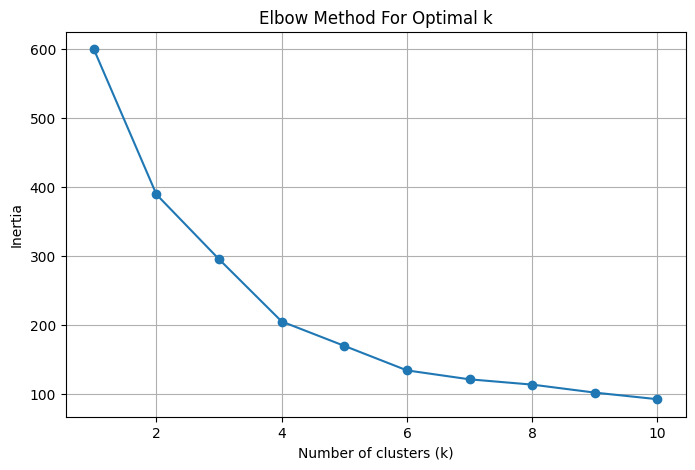

In [9]:
# Elbow Method to Find Optimal k
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = StandardScaler().fit_transform(X)

inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

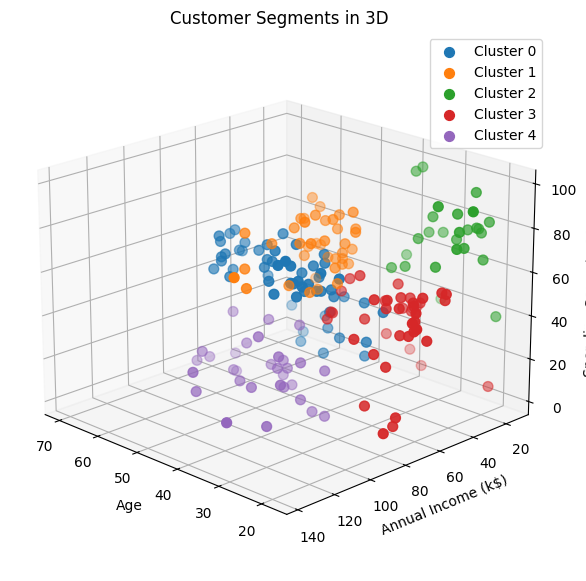

In [10]:
# Apply KMeans and 3D Plot
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    ax.scatter(
        cluster_data['Age'],
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {cluster}',
        s=50
    )

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('Customer Segments in 3D')
ax.view_init(elev=20, azim=135)
ax.legend()
plt.show()

> Explanation: Clustering – Mall Customer Segmentation: In this part of the project, I applied K-Means clustering to the Mall Customer Segmentation dataset using three key features: Age, Annual Income(k$), and Spending Score (1–100). Elbow Method for Optimal k: To determine the optimal number of clusters, I used the elbow method by plotting the inertia (within-cluster sum of squares) against a range of k values from 1 to 10. As shown in the plot, the curve begins to flatten noticeably at k = 5, indicating that five clusters best balance model complexity with explained variance. This point of inflection represents diminishing returns in reducing inertia by adding more clusters. 3D Visualization and Customer Insights: A 3D scatter plot was used to visualize the five clusters across the dimensions of Age, Income, and Spending Score. The clusters show well-separated groupings that reveal meaningful customer segments: Some clusters consist of young high spenders with moderate to high income. Others represent older or lower-spending customers with varying income levels. Notably, when rotating the 3D plot, two distinct high-income groups (Income > $80k) emerge. These groups differ in spending behavior, with one cluster representing high spenders and the other more conservative shoppers, offering actionable insights for targeted marketing strategies. This analysis highlights how clustering combined with dimensional visualization can uncover hidden patterns in consumer behavior, helping businesses tailor their engagement and retention strategies.

# Part 4

Create a new set of toy datasets for regression problems. Come up with your own ideas on different datasets of varying difficulty, that would help you compare the pros & cons of different algorithms. Use these datasets to visualize LinearRegression, Support Vector Regression, Nearest Neighbor Regression, and Decision Trees


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [13]:
# Function to Generate Toy Datasets
def generate_data(complexity='easy', n_samples=100, noise=0.1):
    np.random.seed(42)
    X = np.sort(5 * np.random.rand(n_samples, 1), axis=0)
    
    if complexity == 'easy':
        y = 2 * X.ravel() + 3 + np.random.randn(n_samples) * noise  # Linear
    elif complexity == 'medium':
        y = np.sin(X).ravel() + np.random.randn(n_samples) * noise  # Nonlinear, low noise
    elif complexity == 'hard':
        y = np.sin(1.5 * X).ravel() + 0.5 * np.random.randn(n_samples)  # Nonlinear, high noise
    else:
        raise ValueError("Invalid complexity level.")
    
    return X, y

In [14]:
# Function to Visualize Models on a Dataset
def visualize_models(X, y, title):
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
        "Decision Tree": DecisionTreeRegressor(max_depth=5)
    }

    X_test = np.linspace(0, 5, 500).reshape(-1, 1)

    plt.figure(figsize=(12, 8))
    plt.scatter(X, y, color='black', label='True Data', alpha=0.5)

    for name, model in models.items():
        model.fit(X, y)
        y_pred = model.predict(X_test)
        plt.plot(X_test, y_pred, label=name)

    plt.title(f"Regression Models on {title} Dataset")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

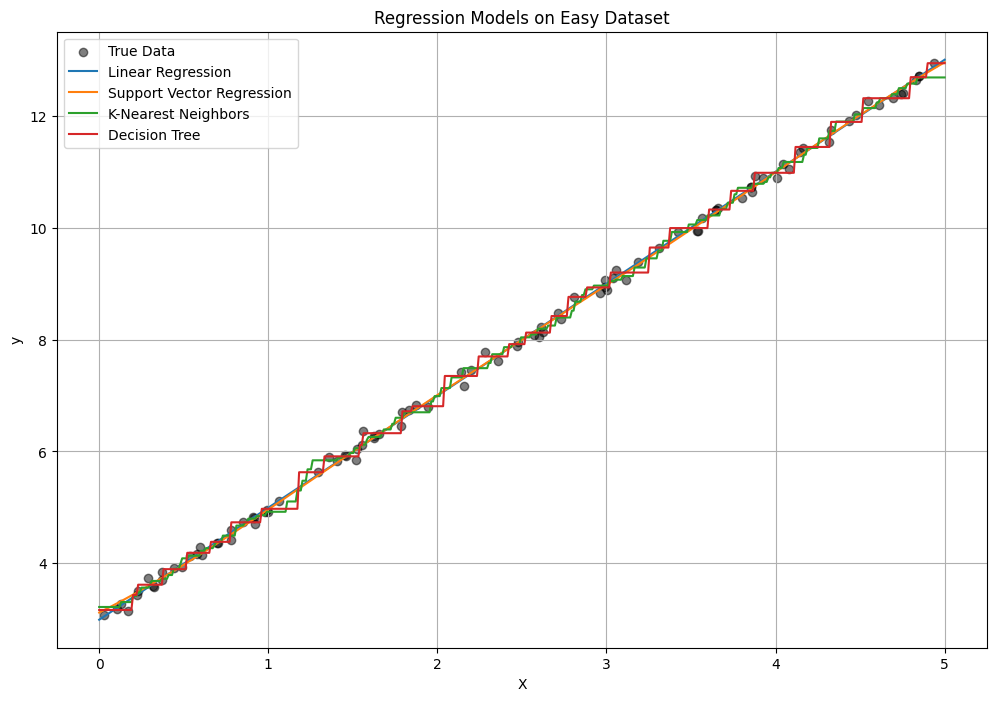

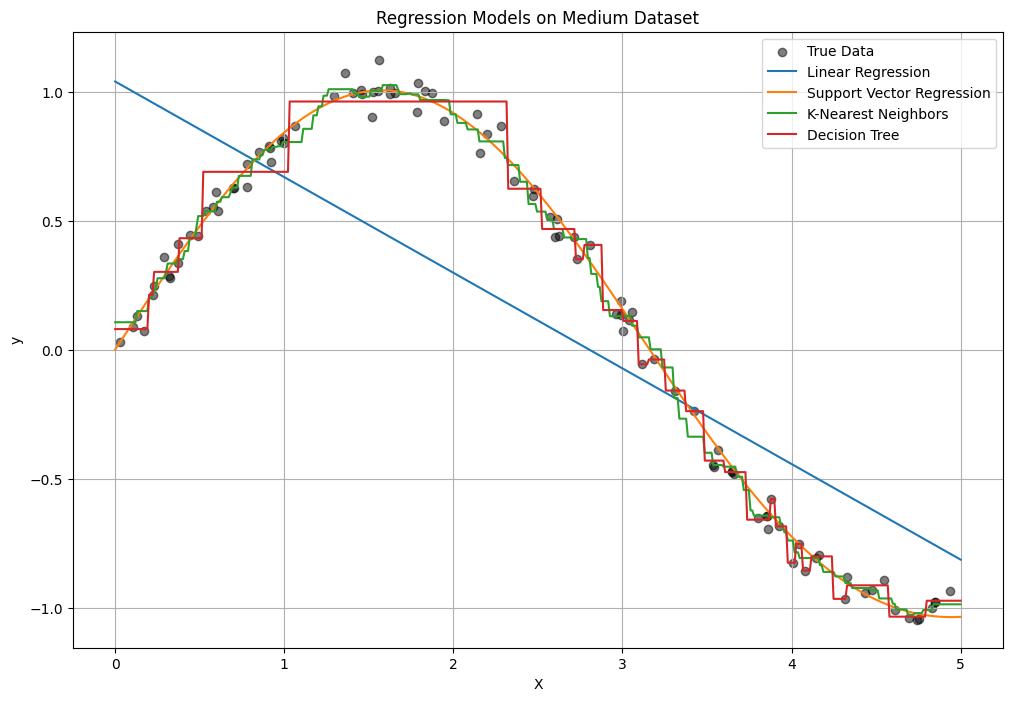

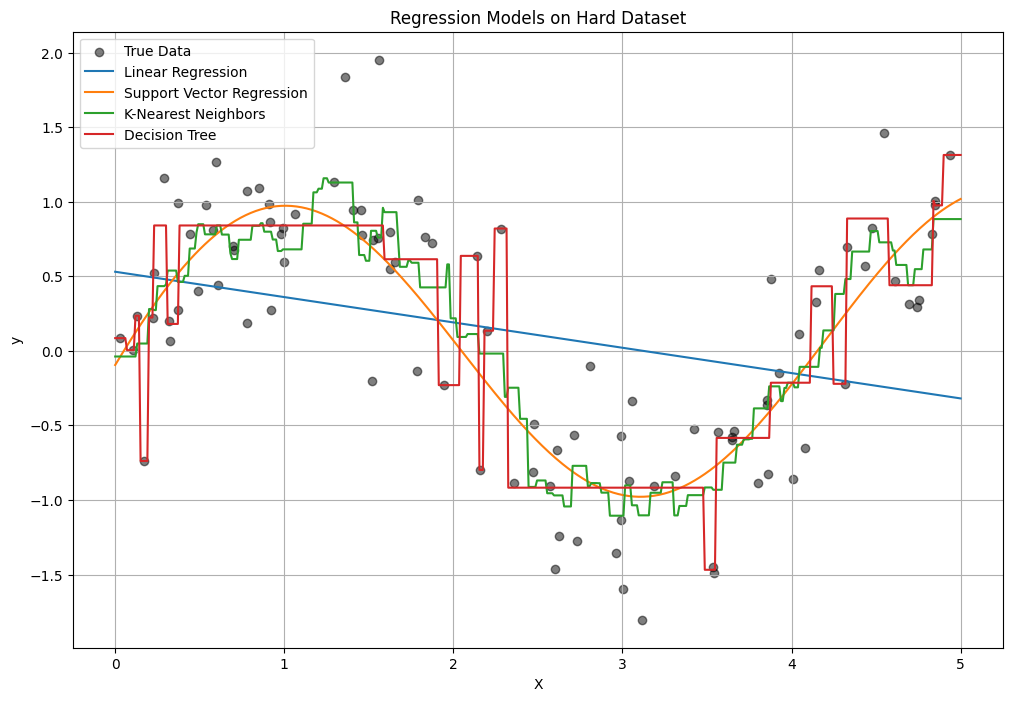

In [15]:
# Run for Each Dataset Difficulty
# Run for EASY (linear, low noise)
X_easy, y_easy = generate_data('easy')
visualize_models(X_easy, y_easy, "Easy")

# Run for MEDIUM (nonlinear, low noise)
X_med, y_med = generate_data('medium', noise=0.05)
visualize_models(X_med, y_med, "Medium")

# Run for HARD (nonlinear, high noise)
X_hard, y_hard = generate_data('hard', noise=0.3)
visualize_models(X_hard, y_hard, "Hard")

> Explanation: This section compared four regression models—Linear Regression, Support Vector Regression (SVR), K-Nearest Neighbors (KNN), and Decision Tree Regression—across three toy datasets of increasing complexity: an easy linear dataset, a medium nonlinear dataset with low noise, and a hard nonlinear dataset with high noise. On the easy dataset, all models performed well, with Linear Regression nearly perfectly fitting the data, as expected. SVR, KNN, and Decision Tree models also approximated the trend effectively, though Decision Trees produced small step-like transitions and KNN introduced slight local variation. The simplicity and low noise level made this dataset well-suited for all four models. The medium dataset introduced nonlinearity. Linear Regression performed poorly here, failing to capture the sinusoidal pattern. SVR and KNN, however, adapted well—SVR offering a smooth curve and KNN closely tracking local variations. Decision Trees followed the overall shape but with abrupt changes at split points. In this case, SVR and KNN provided the most accurate and interpretable results. The hard dataset added both complexity and high noise, highlighting each model’s weaknesses. Linear Regression again failed to model the nonlinear structure. KNN and Decision Trees attempted to fit the noise, resulting in jagged, erratic predictions and clear signs of overfitting. SVR performed best in this scenario, offering a smoother curve that generalized reasonably well despite the noise. Overall, these plots demonstrate that Linear Regression is reliable only for simple, linear data, while SVR provides strong performance on moderately and highly complex datasets. KNN and Decision Trees offer flexibility but are more prone to overfitting when noise is high. This comparison reinforces the importance of selecting regression models that match both the structure and variability of the underlying data.